<a href="https://colab.research.google.com/github/harshsu7/Linear-Regression/blob/main/XGBoost_%26_all_Ensemble_algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [11]:
df = pd.read_csv(r'/content/WineQT.csv')
df.sample(n=5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
62,7.0,0.62,0.08,1.8,0.076,8.0,24.0,0.99780,3.48,0.53,9.0,5,89
884,7.1,0.72,0.00,1.8,0.123,6.0,14.0,0.99627,3.45,0.58,9.8,5,1252
784,8.3,0.53,0.00,1.4,0.070,6.0,14.0,0.99593,3.25,0.64,10.0,6,1110
772,9.2,0.31,0.36,2.2,0.079,11.0,31.0,0.99615,3.33,0.86,12.0,7,1093
1068,7.0,0.43,0.02,1.9,0.080,15.0,28.0,0.99492,3.35,0.81,10.6,6,1495


In [12]:
df["quality"] = np.where(df["quality"] >= 7, 1, 0)

df["quality"].value_counts()

,count
quality,
0,984
1,159


In [13]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

1. Gradient Boosting - boosting algorithm using residual learning

In [17]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:,1]

gb_acc = accuracy_score(y_test, gb_pred)
gb_auc = roc_auc_score(y_test, gb_prob)

print("Gradient Boosting Accuracy:", gb_acc)
print("Gradient Boosting AUC:", gb_auc)

Gradient Boosting Accuracy: 0.9126637554585153
Gradient Boosting AUC: 0.9429637526652452


2. XGBoost = Optimized Gradient Boosting with regularization (L1 & L2)

In [18]:
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost Accuracy:", xgb_acc)
print("XGBoost AUC:", xgb_auc)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:06:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.925764192139738
XGBoost AUC: 0.9436744847192609


3. LightGBM - Fastest boosting model using leaf-wise growth

In [19]:
lgb = LGBMClassifier(n_estimators=100)

lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)
lgb_prob = lgb.predict_proba(X_test)[:,1]

lgb_acc = accuracy_score(y_test, lgb_pred)
lgb_auc = roc_auc_score(y_test, lgb_prob)

print("LightGBM Accuracy:", lgb_acc)
print("LightGBM AUC:", lgb_auc)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 131, number of negative: 783
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1215
[LightGBM] [Info] Number of data points in the train set: 914, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.143326 -> initscore=-1.787935
[LightGBM] [Info] Start training from score -1.787935
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Accuracy: 0.9170305676855895
LightGBM AUC: 0.9422530206112296


4. CatBoost - Handles categorical features automatically (even though we don’t use them here)

In [20]:
cat = CatBoostClassifier(verbose=0)

cat.fit(X_train, y_train)

cat_pred = cat.predict(X_test)
cat_prob = cat.predict_proba(X_test)[:,1]

cat_acc = accuracy_score(y_test, cat_pred)
cat_auc = roc_auc_score(y_test, cat_prob)

print("CatBoost Accuracy:", cat_acc)
print("CatBoost AUC:", cat_auc)

CatBoost Accuracy: 0.9170305676855895
CatBoost AUC: 0.9578891257995736


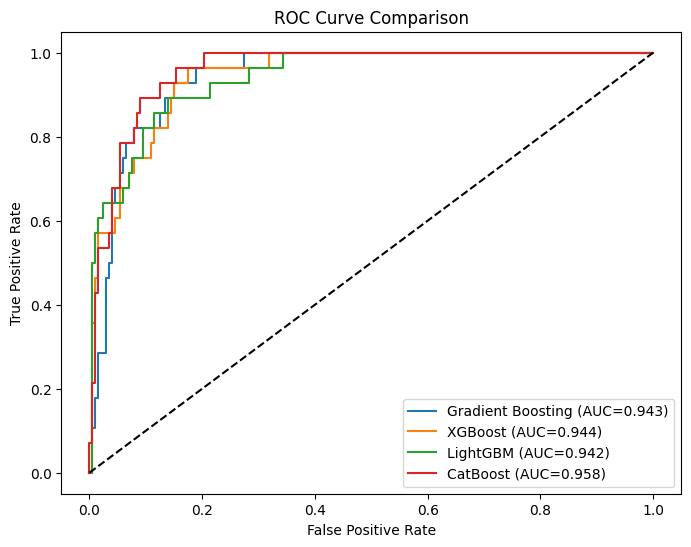

In [21]:
plt.figure(figsize=(8,6))

models = {
    "Gradient Boosting": gb_prob,
    "XGBoost": xgb_prob,
    "LightGBM": lgb_prob,
    "CatBoost": cat_prob
}

for name, prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [22]:
results = pd.DataFrame({
    "Model": ["Gradient Boosting","XGBoost","LightGBM","CatBoost"],
    "Accuracy": [gb_acc, xgb_acc, lgb_acc, cat_acc],
    "AUC": [gb_auc, xgb_auc, lgb_auc, cat_auc]
})

results

,Model,Accuracy,AUC
0,Gradient Boosting,0.912664,0.942964
1,XGBoost,0.925764,0.943674
2,LightGBM,0.917031,0.942253
3,CatBoost,0.917031,0.957889


In [23]:
import matplotlib.pyplot as plt
import pandas as pd

feature_names = X.columns

# Gradient Boosting
gb_imp = pd.Series(gb.feature_importances_, index=feature_names)

# XGBoost
xgb_imp = pd.Series(xgb.feature_importances_, index=feature_names)

# LightGBM
lgb_imp = pd.Series(lgb.feature_importances_, index=feature_names)

# CatBoost
cat_imp = pd.Series(cat.get_feature_importance(), index=feature_names)

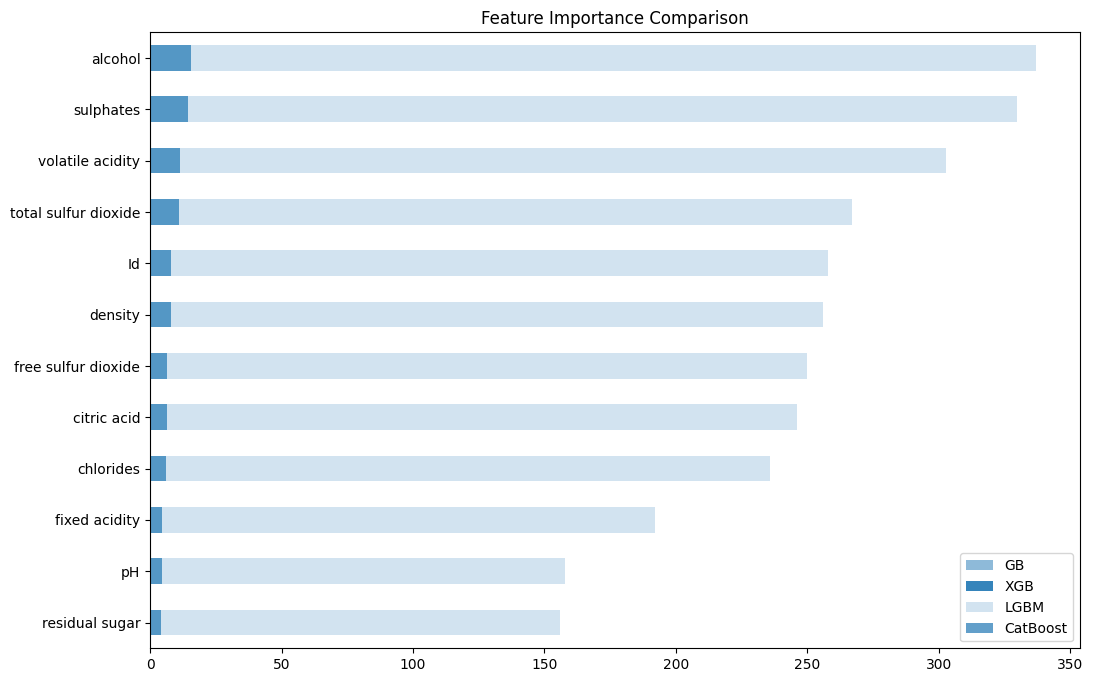

In [29]:
plt.figure(figsize=(12,8))

gb_imp.sort_values().plot(kind='barh', alpha=0.5, label="GB")
xgb_imp.sort_values().plot(kind='barh', alpha=0.9, label="XGB")
lgb_imp.sort_values().plot(kind='barh', alpha=0.2, label="LGBM")
cat_imp.sort_values().plot(kind='barh', alpha=0.7, label="CatBoost")

plt.title("Feature Importance Comparison")
plt.legend()
plt.show()

In [30]:
import time

times = {}

# Gradient Boosting
start = time.time()
gb.fit(X_train, y_train)
times["Gradient Boosting"] = time.time() - start

# XGBoost
start = time.time()
xgb.fit(X_train, y_train)
times["XGBoost"] = time.time() - start

# LightGBM
start = time.time()
lgb.fit(X_train, y_train)
times["LightGBM"] = time.time() - start

# CatBoost
start = time.time()
cat.fit(X_train, y_train)
times["CatBoost"] = time.time() - start

times

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:17:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 131, number of negative: 783
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1215
[LightGBM] [Info] Number of data points in the train set: 914, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.143326 -> initscore=-1.787935
[LightGBM] [Info] Start training from score -1.787935
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


{'Gradient Boosting': 0.7777688503265381,
 'XGBoost': 0.20893073081970215,
 'LightGBM': 0.1862483024597168,
 'CatBoost': 4.052408695220947}

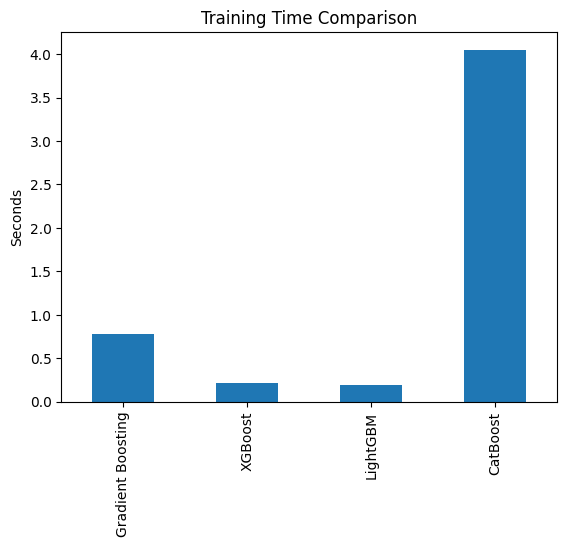

In [31]:
pd.Series(times).plot(kind='bar')

plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.show()